# Predicting Your Future with Data
A supervised classification model + recommendation system built on the **Adult Census Income** dataset.
The goal is to predict whether a person earns **>50K / year** and recommend socioeconomic paths that can improve that probability.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


## 2. Load the Dataset

In [2]:
df = pd.read_csv('adult-census-income.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Data Preprocessing

In [3]:
# Replace '?' with NaN and drop missing rows
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Strip whitespace from string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Binary target: 1 if income > 50K else 0
df['high_income'] = (df['income'] == '>50K').astype(int)

print('Income distribution after cleaning:')
print(df['high_income'].value_counts())
print(f'\nDataset size after removing missing values: {df.shape}')

Income distribution after cleaning:
high_income
0    22654
1     7508
Name: count, dtype: int64

Dataset size after removing missing values: (30162, 16)


## 4. Exploratory Data Analysis

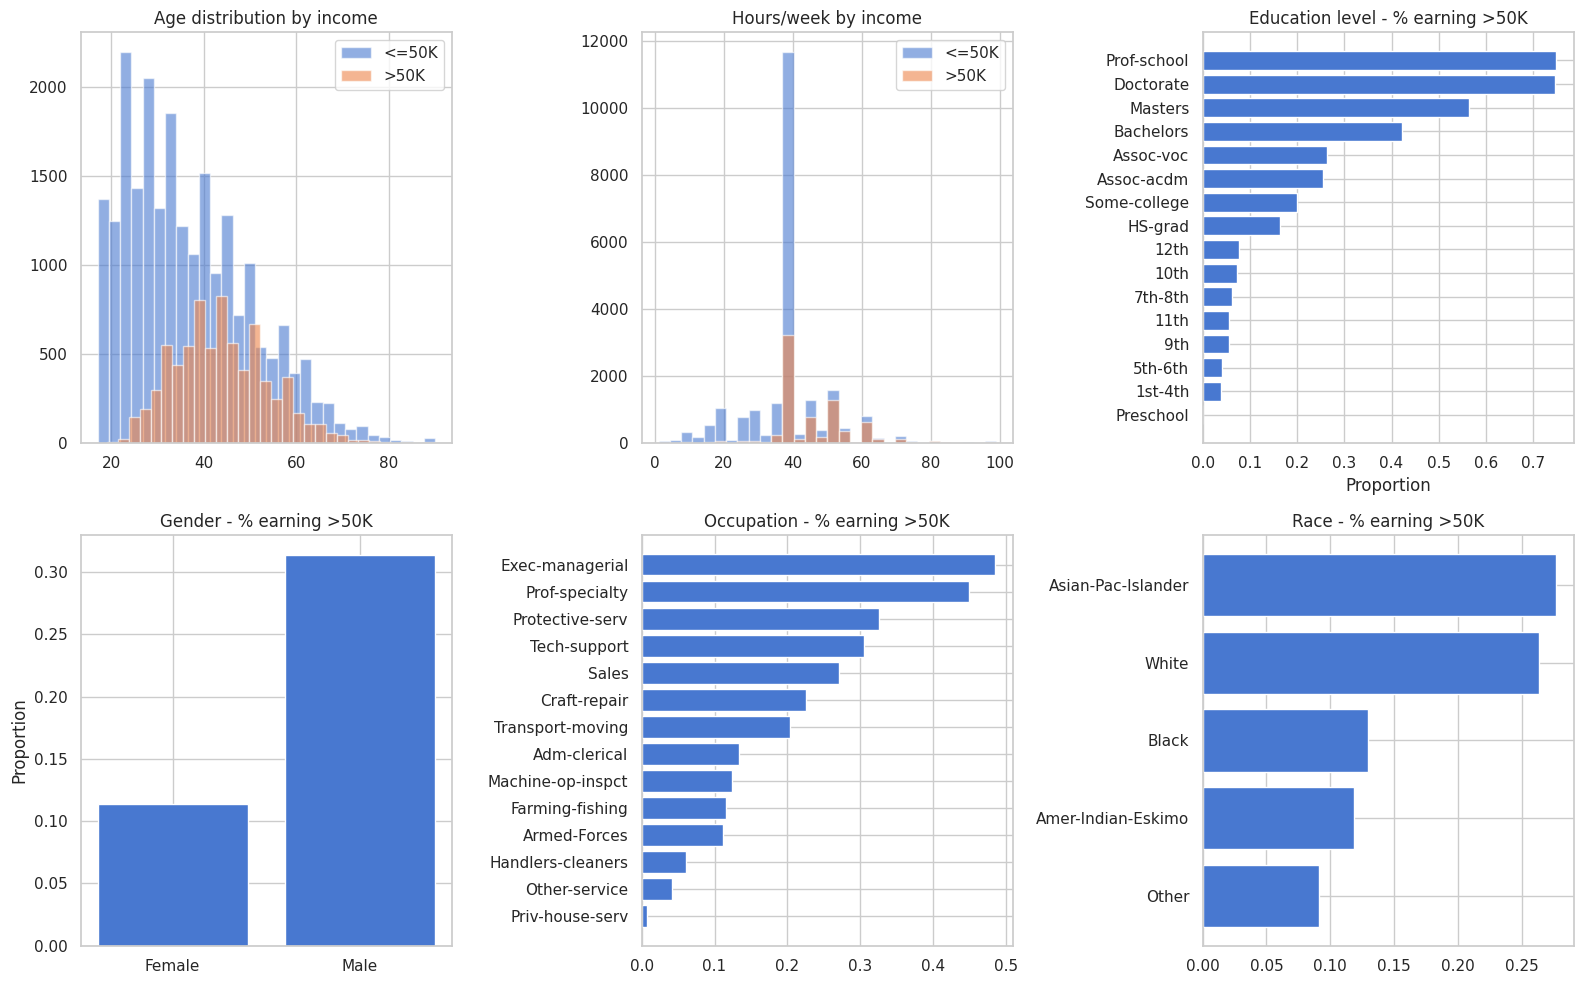

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age distribution
axes[0, 0].hist(df[df.high_income==0]['age'], bins=30, alpha=0.6, label='<=50K')
axes[0, 0].hist(df[df.high_income==1]['age'], bins=30, alpha=0.6, label='>50K')
axes[0, 0].set_title('Age distribution by income')
axes[0, 0].legend()

# Hours per week
axes[0, 1].hist(df[df.high_income==0]['hours.per.week'], bins=30, alpha=0.6, label='<=50K')
axes[0, 1].hist(df[df.high_income==1]['hours.per.week'], bins=30, alpha=0.6, label='>50K')
axes[0, 1].set_title('Hours/week by income')
axes[0, 1].legend()

# Education level vs income
edu_rate = df.groupby('education')['high_income'].mean().sort_values()
axes[0, 2].barh(edu_rate.index, edu_rate.values)
axes[0, 2].set_title('Education level - % earning >50K')
axes[0, 2].set_xlabel('Proportion')

# Gender income gap
sex_rate = df.groupby('sex')['high_income'].mean()
axes[1, 0].bar(sex_rate.index, sex_rate.values)
axes[1, 0].set_title('Gender - % earning >50K')
axes[1, 0].set_ylabel('Proportion')

# Occupation vs income
occ_rate = df.groupby('occupation')['high_income'].mean().sort_values()
axes[1, 1].barh(occ_rate.index, occ_rate.values)
axes[1, 1].set_title('Occupation - % earning >50K')

# Race vs income
race_rate = df.groupby('race')['high_income'].mean().sort_values()
axes[1, 2].barh(race_rate.index, race_rate.values)
axes[1, 2].set_title('Race - % earning >50K')

plt.tight_layout()
plt.show()

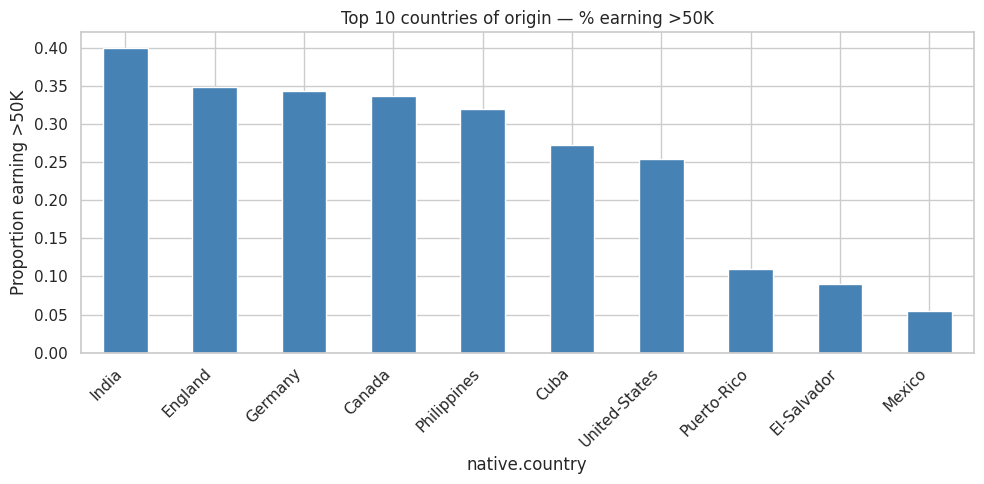

In [5]:
# Top 10 countries by number of records and their income rate
top_countries = df['native.country'].value_counts().head(10).index
country_df = df[df['native.country'].isin(top_countries)]
ct = country_df.groupby('native.country')['high_income'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ct.plot(kind='bar', color='steelblue')
plt.title('Top 10 countries of origin — % earning >50K')
plt.ylabel('Proportion earning >50K')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Build the Classification Model

We select the most relevant sociodemographic features, preprocess them with a `ColumnTransformer` pipeline, and train a **Random Forest** classifier.

In [6]:
FEATURES = [
    'age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss',
    'education', 'marital.status', 'occupation', 'relationship', 'sex',
    'race', 'native.country', 'workclass'
]

X = df[FEATURES]
y = df['high_income']

NUMERIC = ['age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss']
CATEGORICAL = ['education', 'marital.status', 'occupation', 'relationship', 'sex',
               'race', 'native.country', 'workclass']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)
print('Model trained!')

Model trained!


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4531
        >50K       0.73      0.65      0.69      1502

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.80      6033
weighted avg       0.85      0.85      0.85      6033



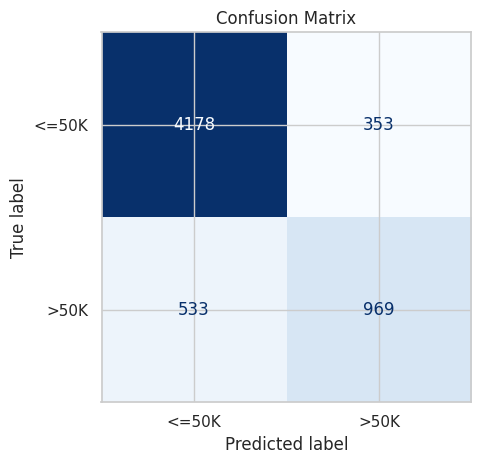

In [7]:
y_pred = model.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

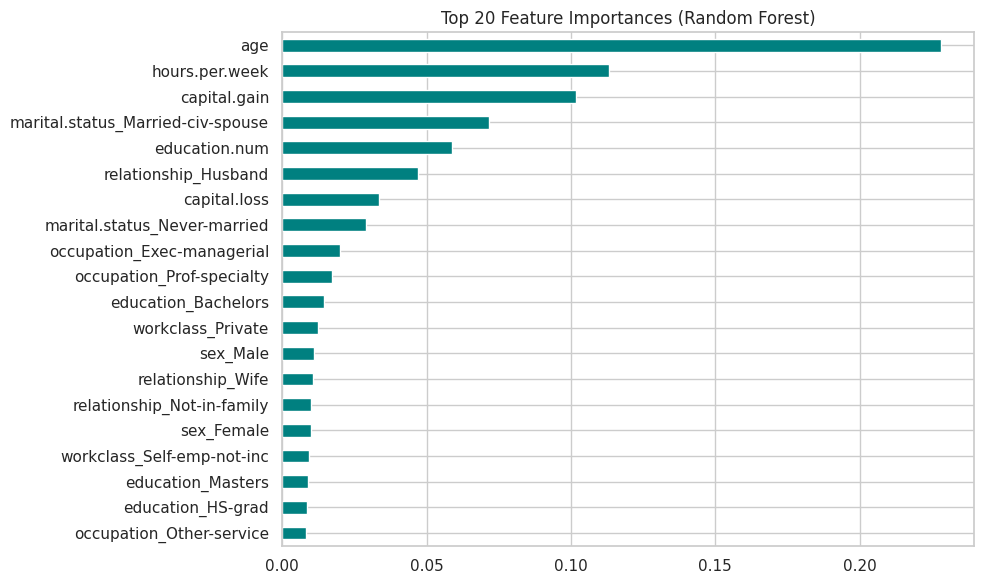

In [8]:
# Feature importances from the Random Forest
rf = model.named_steps['classifier']
ohe_cols = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(CATEGORICAL)
all_feature_names = NUMERIC + list(ohe_cols)

feat_imp = pd.Series(rf.feature_importances_, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Recommendation System

### Design
- **What is being recommended?** Socioeconomic trajectories (education level, occupation, relationship status, hours worked) that improve the probability of earning >50K.
- **Who is the user?** A hypothetical adult described by their demographic/socioeconomic profile.
- **Approach:** *Content-based + counterfactual reasoning* — we generate candidate profiles by modifying the user's key variables, score each variation with the classifier, and surface the highest-probability alternatives as recommendations.

This gives interpretable, actionable suggestions per user.

In [9]:
# Education ladder in ascending order
EDU_LEVELS = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
    'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]
EDU_NUM = {edu: idx + 1 for idx, edu in enumerate(EDU_LEVELS)}

# High-earning occupations (from EDA)
HIGH_OCC = ['Exec-managerial', 'Prof-specialty', 'Tech-support', 'Protective-serv']


def make_profile_df(profile: dict) -> pd.DataFrame:
    """Convert a user profile dict to a DataFrame row compatible with the model."""
    row = {f: profile.get(f) for f in FEATURES}
    return pd.DataFrame([row])


def predict_income_prob(profile: dict) -> float:
    """Return probability of earning >50K for a given profile dict."""
    return model.predict_proba(make_profile_df(profile))[0][1]


def recommend_trajectory(user_profile: dict, verbose: bool = True) -> dict:
    """
    Generate recommendations for a user profile.
    Returns base probability and a list of suggested changes ranked by uplift.
    """
    base_prob = predict_income_prob(user_profile)
    recommendations = []

    # --- Recommendation 1: improve education level ---
    current_edu = user_profile['education']
    if current_edu in EDU_LEVELS:
        current_idx = EDU_LEVELS.index(current_edu)
        for higher_edu in EDU_LEVELS[current_idx + 1:]:
            candidate = user_profile.copy()
            candidate['education'] = higher_edu
            candidate['education.num'] = EDU_NUM[higher_edu]
            prob = predict_income_prob(candidate)
            uplift = prob - base_prob
            if uplift > 0.01:
                recommendations.append({
                    'change': f'Improve education to {higher_edu}',
                    'new_prob': prob,
                    'uplift': uplift
                })

    # --- Recommendation 2: switch to high-earning occupation ---
    for occ in HIGH_OCC:
        if occ != user_profile.get('occupation'):
            candidate = user_profile.copy()
            candidate['occupation'] = occ
            prob = predict_income_prob(candidate)
            uplift = prob - base_prob
            if uplift > 0.01:
                recommendations.append({
                    'change': f'Switch occupation to {occ}',
                    'new_prob': prob,
                    'uplift': uplift
                })

    # --- Recommendation 3: increase hours per week (up to 55 h) ---
    for extra_hours in [40, 45, 50, 55]:
        if extra_hours > user_profile['hours.per.week']:
            candidate = user_profile.copy()
            candidate['hours.per.week'] = extra_hours
            prob = predict_income_prob(candidate)
            uplift = prob - base_prob
            if uplift > 0.01:
                recommendations.append({
                    'change': f'Increase hours/week to {extra_hours}',
                    'new_prob': prob,
                    'uplift': uplift
                })

    # Sort by highest uplift
    recommendations.sort(key=lambda x: x['uplift'], reverse=True)

    if verbose:
        print(f"Base probability of earning >50K: {base_prob*100:.1f}%")
        if not recommendations:
            print('Already in a high percentile — maintain current trajectory!')
        else:
            print('\nTop recommendations to improve income probability:')
            for i, r in enumerate(recommendations[:5], 1):
                print(f'  {i}. {r["change"]}  →  {r["new_prob"]*100:.1f}%  (uplift +{r["uplift"]*100:.1f}%)')

    return {'base_prob': base_prob, 'recommendations': recommendations[:5]}


print('Recommendation engine ready.')

Recommendation engine ready.


## 7. Test with Simulated User Profiles

In [10]:
# Profile 1: 25-year-old, high school graduate, part-time sales worker
user1 = {
    'age': 25,
    'education': 'HS-grad',
    'education.num': EDU_NUM['HS-grad'],
    'marital.status': 'Never-married',
    'occupation': 'Sales',
    'relationship': 'Not-in-family',
    'race': 'White',
    'sex': 'Male',
    'native.country': 'United-States',
    'workclass': 'Private',
    'hours.per.week': 30,
    'capital.gain': 0,
    'capital.loss': 0
}

print('=== Profile 1: 25-year-old HS graduate, part-time sales ===')
result1 = recommend_trajectory(user1)

=== Profile 1: 25-year-old HS graduate, part-time sales ===


Base probability of earning >50K: 0.0%

Top recommendations to improve income probability:
  1. Improve education to Doctorate  →  34.0%  (uplift +34.0%)
  2. Increase hours/week to 50  →  24.0%  (uplift +24.0%)
  3. Improve education to Assoc-voc  →  12.0%  (uplift +12.0%)
  4. Improve education to Prof-school  →  12.0%  (uplift +12.0%)
  5. Increase hours/week to 55  →  9.0%  (uplift +9.0%)


In [11]:
# Profile 2: 35-year-old woman from Mexico, some college, clerical work
user2 = {
    'age': 35,
    'education': 'Some-college',
    'education.num': EDU_NUM['Some-college'],
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Adm-clerical',
    'relationship': 'Wife',
    'race': 'White',
    'sex': 'Female',
    'native.country': 'Mexico',
    'workclass': 'Private',
    'hours.per.week': 40,
    'capital.gain': 0,
    'capital.loss': 0
}

print('=== Profile 2: 35-year-old woman from Mexico, some college, clerical ===')
result2 = recommend_trajectory(user2)

=== Profile 2: 35-year-old woman from Mexico, some college, clerical ===


Base probability of earning >50K: 28.3%

Top recommendations to improve income probability:
  1. Switch occupation to Exec-managerial  →  73.0%  (uplift +44.7%)
  2. Switch occupation to Prof-specialty  →  68.0%  (uplift +39.7%)
  3. Improve education to Assoc-acdm  →  62.0%  (uplift +33.7%)
  4. Improve education to Prof-school  →  52.5%  (uplift +24.2%)
  5. Increase hours/week to 50  →  50.5%  (uplift +22.2%)


In [12]:
# Profile 3: 45-year-old man with a Bachelors degree, exec-managerial, married
user3 = {
    'age': 45,
    'education': 'Bachelors',
    'education.num': EDU_NUM['Bachelors'],
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'native.country': 'United-States',
    'workclass': 'Self-emp-not-inc',
    'hours.per.week': 50,
    'capital.gain': 5000,
    'capital.loss': 0
}

print('=== Profile 3: 45-year-old Bachelors exec-manager, married ===')
result3 = recommend_trajectory(user3)

=== Profile 3: 45-year-old Bachelors exec-manager, married ===


Base probability of earning >50K: 54.0%

Top recommendations to improve income probability:
  1. Improve education to Prof-school  →  78.0%  (uplift +24.0%)
  2. Improve education to Doctorate  →  73.0%  (uplift +19.0%)
  3. Improve education to Masters  →  72.0%  (uplift +18.0%)
  4. Switch occupation to Tech-support  →  62.7%  (uplift +8.7%)
  5. Increase hours/week to 55  →  55.0%  (uplift +1.0%)


## 8. Visualising Recommendations

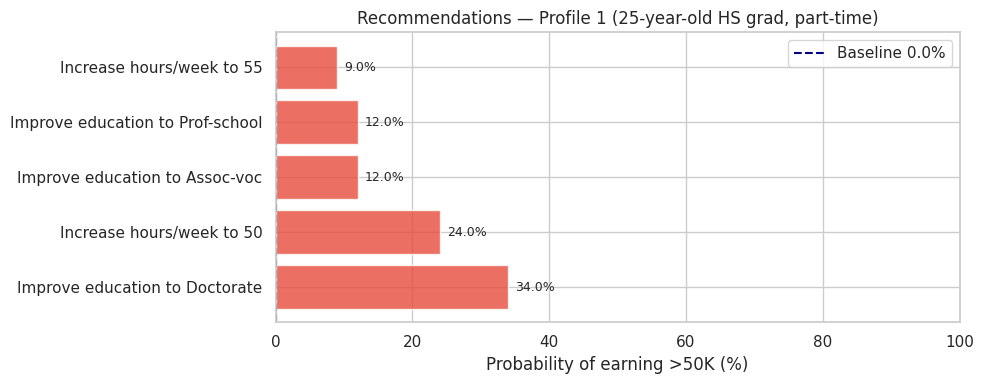

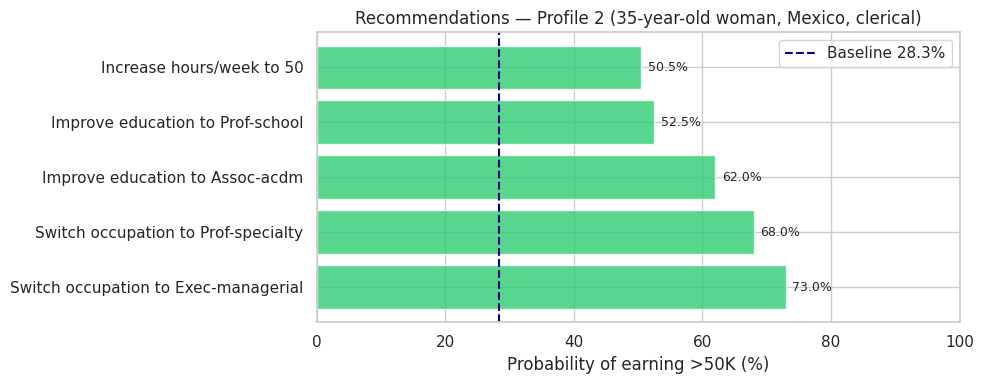

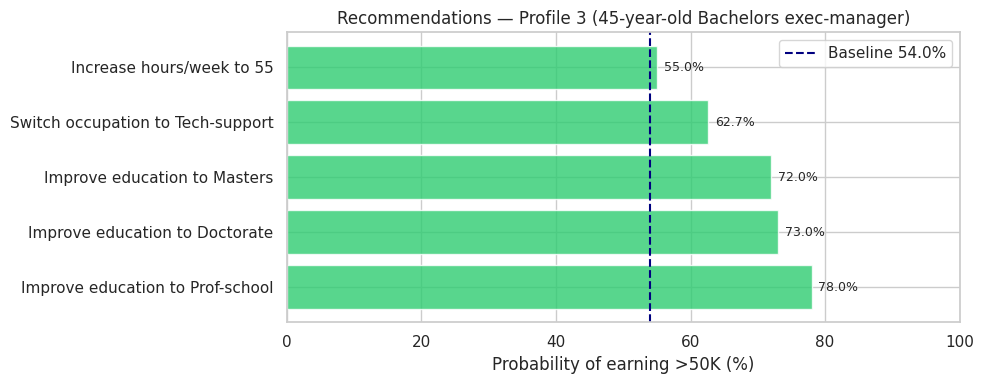

In [13]:
def plot_recommendations(result: dict, title: str):
    recs = result['recommendations']
    if not recs:
        print('No significant improvements found — already at a high probability!')
        return
    labels = [r['change'] for r in recs]
    probs  = [r['new_prob'] * 100 for r in recs]
    base   = result['base_prob'] * 100

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#2ecc71' if p > 50 else '#e74c3c' for p in probs]
    bars = ax.barh(labels, probs, color=colors, alpha=0.8)
    ax.axvline(base, color='navy', linestyle='--', linewidth=1.5, label=f'Baseline {base:.1f}%')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probability of earning >50K (%)')
    ax.set_title(title)
    ax.legend()

    for bar, prob in zip(bars, probs):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'{prob:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


plot_recommendations(result1, 'Recommendations — Profile 1 (25-year-old HS grad, part-time)')
plot_recommendations(result2, 'Recommendations — Profile 2 (35-year-old woman, Mexico, clerical)')
plot_recommendations(result3, 'Recommendations — Profile 3 (45-year-old Bachelors exec-manager)')

## 9. Key Insights

### What Has the Greatest Impact on Income?

Based on the Random Forest feature importances and comparative experiments:

| Factor | Impact on >50K probability |
|---|---|
| **Education level** | Very high — moving from HS-grad to Bachelors/Masters is the single biggest lever |
| **Occupation (Exec-managerial / Prof-specialty)** | High — switching career track gives significant uplift |
| **Capital gains** | High — reflects wealth that compounds income |
| **Age (experience)** | Moderate — income peaks in the 40-55 age range |
| **Hours per week** | Moderate — working more helps, but less than improving education |
| **Gender (Male)** | Moderate — statistically the data reflects a systemic gap |
| **Country of origin** | Low–moderate — US-born individuals have a statistical advantage |

### Key Takeaway
> **Education is the highest-return investment**: upgrading from a high school diploma to a Bachelor's degree can increase the predicted >50K probability by 10–20 percentage points for a typical profile. Doubling work hours gives a much smaller boost.
>
> Systemic disparities tied to gender and country of origin are visible in the data — variables a person cannot change. The most actionable levers are education, occupation, and strategic career development.